In [2]:
'''
imports and loading dataset
'''
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, recall_score
X_train = pd.read_csv('../output/x_train.csv')
X_test = pd.read_csv('../output/x_test.csv')
y_train = pd.read_csv('../output/y_train.csv')
y_test = pd.read_csv('../output/y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [3]:
'''
preparing data
- applying the features
'''
the_scaler = StandardScaler()
scaled_X_train = the_scaler.fit_transform(X_train)
scaled_X_test = the_scaler.transform(X_test)

In [4]:
'''
training logistic regression model
'''
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logistic_regression.fit(scaled_X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
'''
evaluating models
- accuracy
- precision
- recall
- f1 score
'''
y_prediction = logistic_regression.predict(scaled_X_test)
print("accuracy: ", accuracy_score(y_test,y_prediction))
print("precision: ", precision_score(y_test,y_prediction,average='weighted'))
print("recall: ", recall_score(y_test,y_prediction,average='weighted'))
print("f1 score: ", f1_score(y_test,y_prediction,average='weighted'))
print("\nclassification report:\n", classification_report(y_test,y_prediction))

accuracy:  0.41911764705882354
precision:  0.5503115028985843
recall:  0.41911764705882354
f1 score:  0.4621127656745618

classification report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.27      0.11        11
           5       0.71      0.57      0.63       116
           6       0.52      0.27      0.36       107
           7       0.34      0.48      0.40        33
           8       0.00      0.00      0.00         3

    accuracy                           0.42       272
   macro avg       0.27      0.27      0.25       272
weighted avg       0.55      0.42      0.46       272



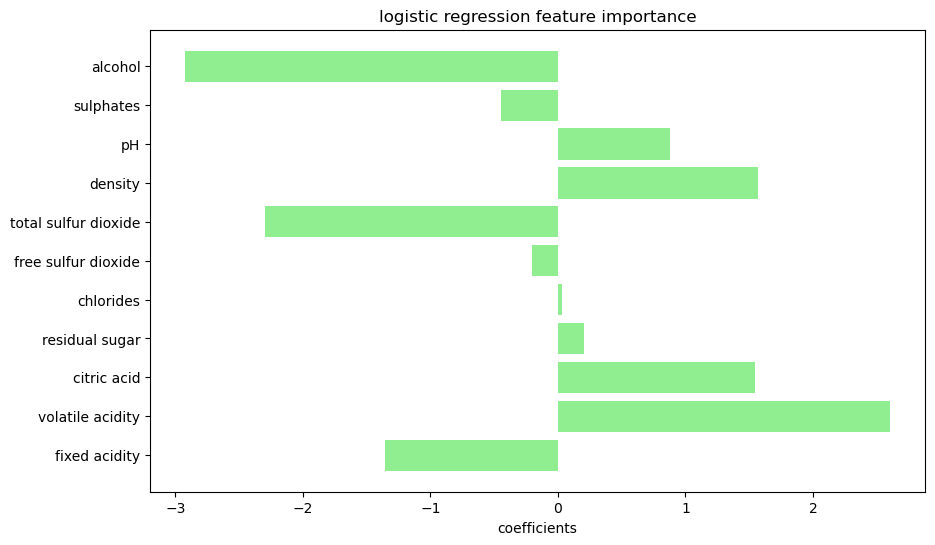

In [7]:
'''
featuring importance: find which features has the most influence on quality determination
'''
coefficient = logistic_regression.coef_[0]
features = X_train.columns
plt.figure(figsize=(10,6))
plt.barh(features,coefficient,color='lightgreen')
plt.xlabel("coefficients")
plt.title("logistic regression feature importance")
plt.show()